In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

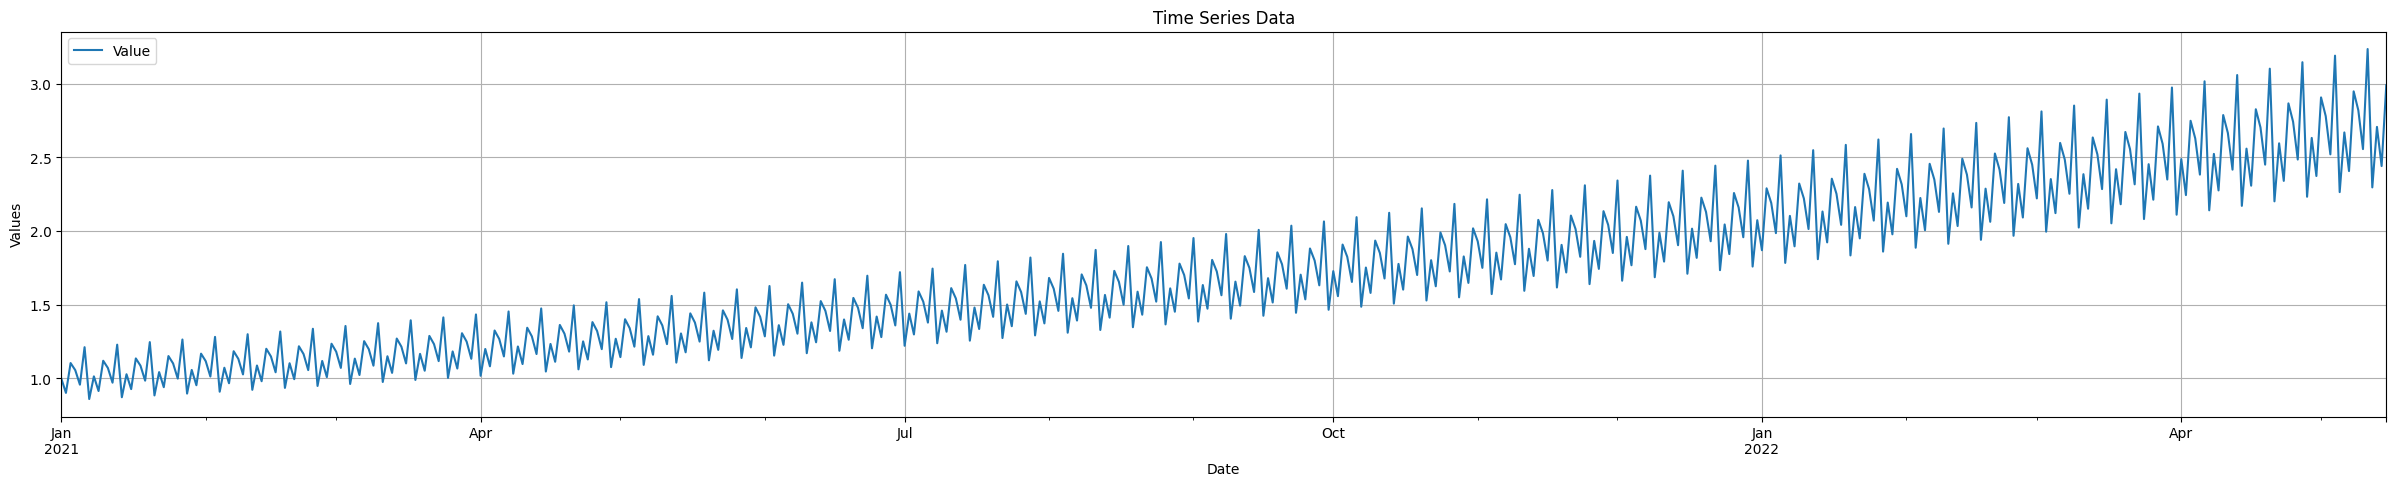

In [ ]:
ts = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/time_series_data_018.csv',index_col = 'Date', parse_dates = True)
ts.plot(figsize = (30,5), grid = True, ylabel = 'Values', title = 'Time Series Data')
plt.show()

In [ ]:
ts

,Value
Date,
2021-01-01,1.000000
2021-01-02,0.901805
2021-01-03,1.104418
2021-01-04,1.056332
2021-01-05,0.957646
...,...
2022-05-11,3.235895
2022-05-12,2.296690
2022-05-13,2.707409


In [ ]:
from statsmodels.tsa.seasonal import STL

ts_stl = STL(ts["Value"], robust = True)
decomp_stl = ts_stl.fit()

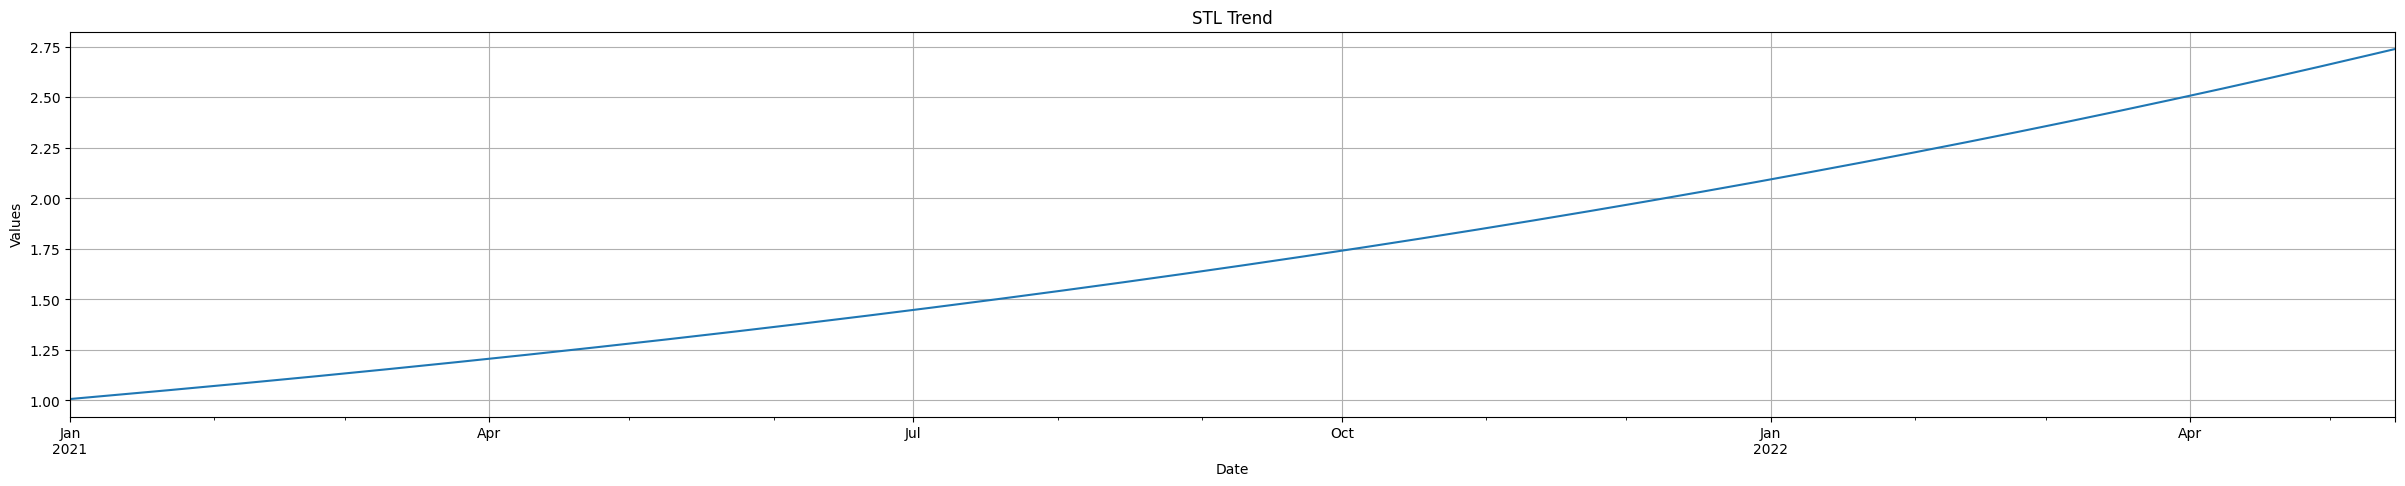

In [ ]:
decomp_stl.trend.plot(figsize = (30,5), grid = True, ylabel = 'Values', title = 'STL Trend')
plt.show()

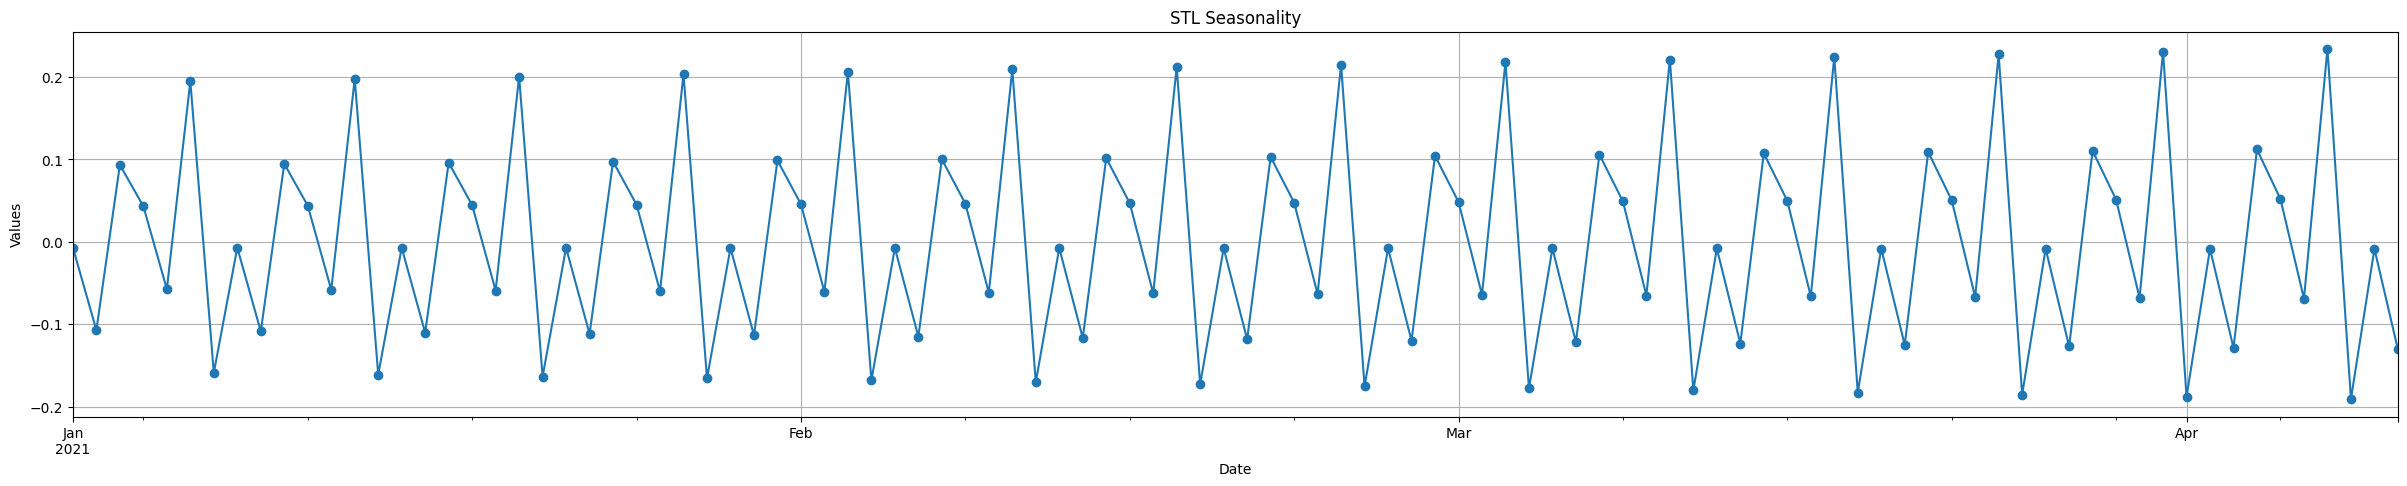

In [ ]:
decomp_stl.seasonal[:100].plot(figsize = (30,5), grid = True, ylabel = 'Values', title = 'STL Seasonality', marker = 'o')
plt.show()

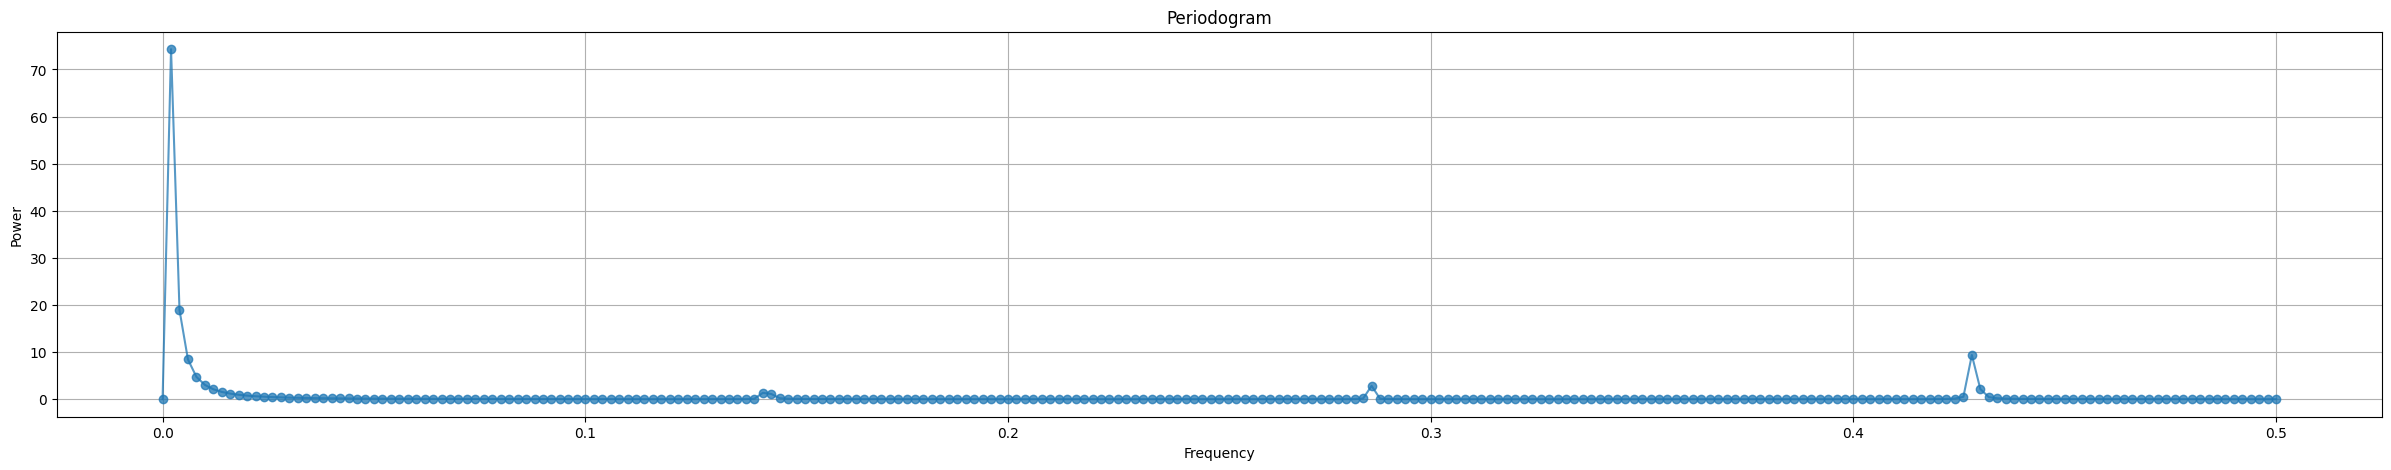

In [ ]:
from scipy.signal import periodogram

frequencies, power = periodogram(ts['Value'])
plt.figure(figsize=(30, 5))
plt.plot(frequencies, power, marker='o', linestyle='-', alpha = 0.75)
plt.title("Periodogram")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)
plt.show()

# 1. What is the best model for the time series data.
#  **C. TES**

In [ ]:
forecast_horizon = 30

ts = ts.asfreq('D')
train_data = ts.iloc[:-forecast_horizon]
test_data = ts.iloc[-forecast_horizon:]

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

tes_model = ExponentialSmoothing(
    train_data['Value'],
    trend='multiplicative',
    seasonal='multiplicative',
    seasonal_periods=7
).fit()

tes_pred = tes_model.forecast(forecast_horizon)


# 2. Trend category - **multiplicative**
# Seasonal category - **multiplicative**
# Optimal seasonal period - **7**

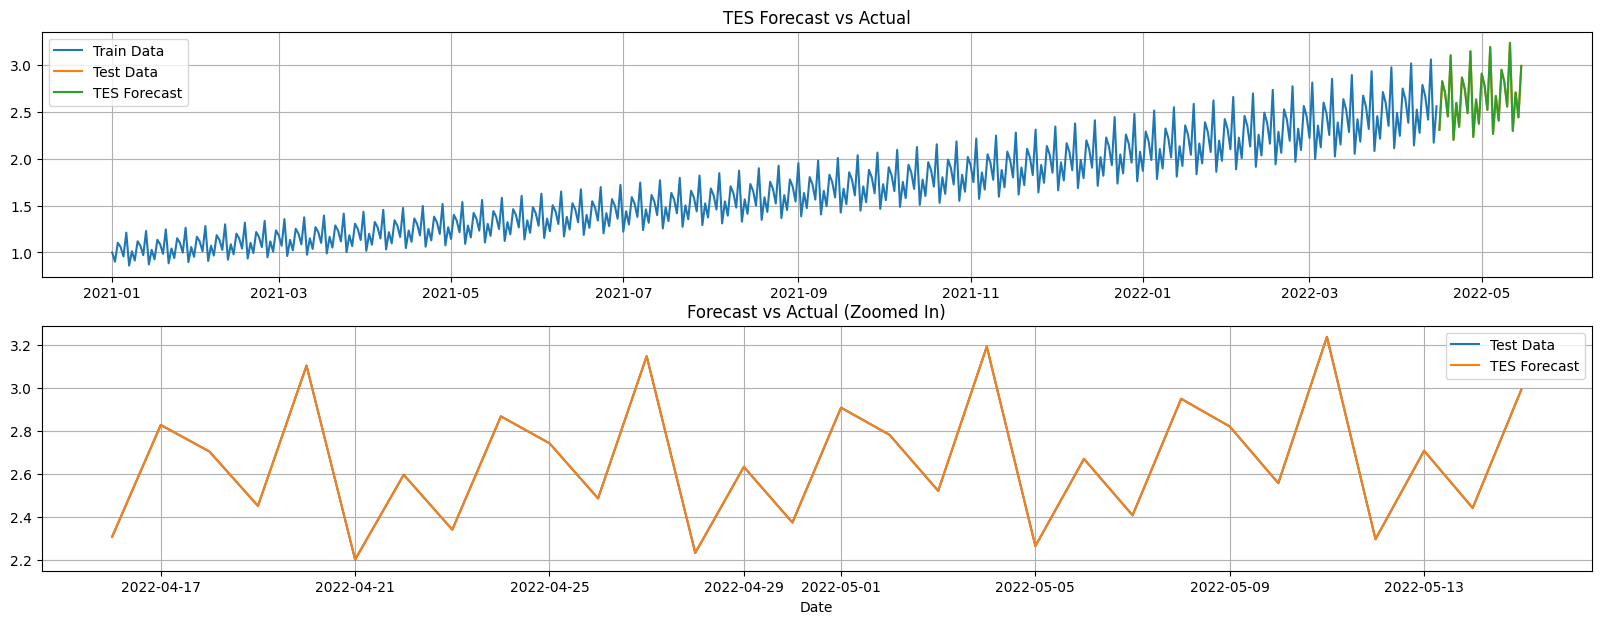

In [ ]:
plt.figure(figsize=(20, 7))
plt.subplot(2, 1, 1)
plt.plot(train_data.index, train_data['Value'], label='Train Data')
plt.plot(test_data.index, test_data['Value'], label='Test Data')
plt.plot(tes_pred.index, tes_pred, label='TES Forecast')
plt.legend()
plt.grid()
plt.title('TES Forecast vs Actual')

plt.subplot(2, 1, 2)
plt.plot(test_data.index, test_data['Value'], label='Test Data')
plt.plot(tes_pred.index, tes_pred, label='TES Forecast')
plt.legend()
plt.grid()
plt.xlabel('Date')
plt.title('Forecast vs Actual (Zoomed In)')
plt.show()

In [ ]:
y_true = test_data['Value'].values
y_pred = tes_pred.values

# Compute metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

# Display results
print(f"3. Using your best model, write the MAE, MSE, RMSE, and MAPE values.")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")


3. Using your best model, write the MAE, MSE, RMSE, and MAPE values.
MAE: 3.087291093852862e-05
MSE: 1.2741670105156851e-09
RMSE: 3.5695476051114445e-05
MAPE: 1.1311801558406137e-05


In [ ]:
full_model = ExponentialSmoothing(
    ts['Value'],
    trend='multiplicative',
    seasonal='multiplicative',
    seasonal_periods=7
).fit()

forecast_30 = full_model.forecast(30)

print(f"4. Using your best model (at 30 days test set), what is the forecast at 2022-05-22?")
print("Forecast at 2022-05-22:", forecast_30['2022-05-22'])
print(f"\n5. Using your best model (with forecast horizon of 30), what is the forecast at 2022-06-08?")
print("Forecast at 2022-06-08:", forecast_30['2022-06-08'])

4. Using your best model (at 30 days test set), what is the forecast at 2022-05-22?
Forecast at 2022-05-22: 3.032350587893057

5. Using your best model (with forecast horizon of 30), what is the forecast at 2022-06-08?
Forecast at 2022-06-08: 3.4226545464558815


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Reinstall numpy and pmdarima
#!pip install --upgrade --force-reinstall numpy
#!pip install --upgrade --force-reinstall --no-cache-dir pmdarima
#!pip install pmdarima==2.0.4 -q
#!pip uninstall -y numpy
#!pip install --no-cache-dir --force-reinstall numpy==1.26.4
import warnings
warnings.filterwarnings('ignore')



In [ ]:
from pmdarima import auto_arima # Import after reinstalling

In [ ]:
ts = pd.read_csv(
    'https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/time_series_data_018.csv',
    index_col='Date', parse_dates=True
)

# Set frequency and split data
ts = ts.asfreq('D')
forecast_horizon = 30
train_data = ts.iloc[:-forecast_horizon]
test_data = ts.iloc[-forecast_horizon:]


In [ ]:
model = auto_arima(train_data['Value'], m = 7)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  470
Model:             SARIMAX(2, 1, 2)x(1, 1, 2, 7)   Log Likelihood                3707.463
Date:                           Tue, 15 Apr 2025   AIC                          -7398.926
Time:                                   04:31:41   BIC                          -7365.841
Sample:                               01-01-2021   HQIC                         -7385.900
                                    - 04-15-2022                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2413      0.001   -170.175      0.000      -0.244      -0.239
ar.L2          0.7306      0.002    342.931      0.000       0.726       0.735
ma.L1         -1.5500      0.007   -216.230      0.000      -1.564      -1.536
ma.L2          0.7307      0.007     99.617      0.000       0.716       0.745
ar.S.L7        0.9353      0.004    256.644      0.000       0.928       0.942
ma.S.L7        1.7623   1.42e-05   1.24e+05      0.000       1.762       1.762
ma.S.L14       0.8614   6.98e-05   1.23e+04      0.000       0.861       0.862
sigma2      5.017e-09   5.16e-10      9.725      0.000    4.01e-09    6.03e-09
===================================================================================
Ljung-Box (L1) (Q):                  27.25   Jarque-Bera (JB):                 4.79
Prob(Q):                              0.00   Prob(JB):                         0.09
Heteroskedasticity (H):               2.03   Skew:                            -0.25
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.63e+21. Standard errors may be unstable.
"""

# 1. What is the best model for the same time series?
  # B. SARIMA

# 2. Best Configuration: SARIMAX(2, 1, 2)x(1, 1, 2, [7])

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [ ]:
sarima_model = SARIMAX(
    train_data['Value'],
    order=(2, 1, 2),  # ARIMA(p,d,q) order
    seasonal_order=(1, 1, 2, 7),  # Seasonal order (P,D,Q,S)
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

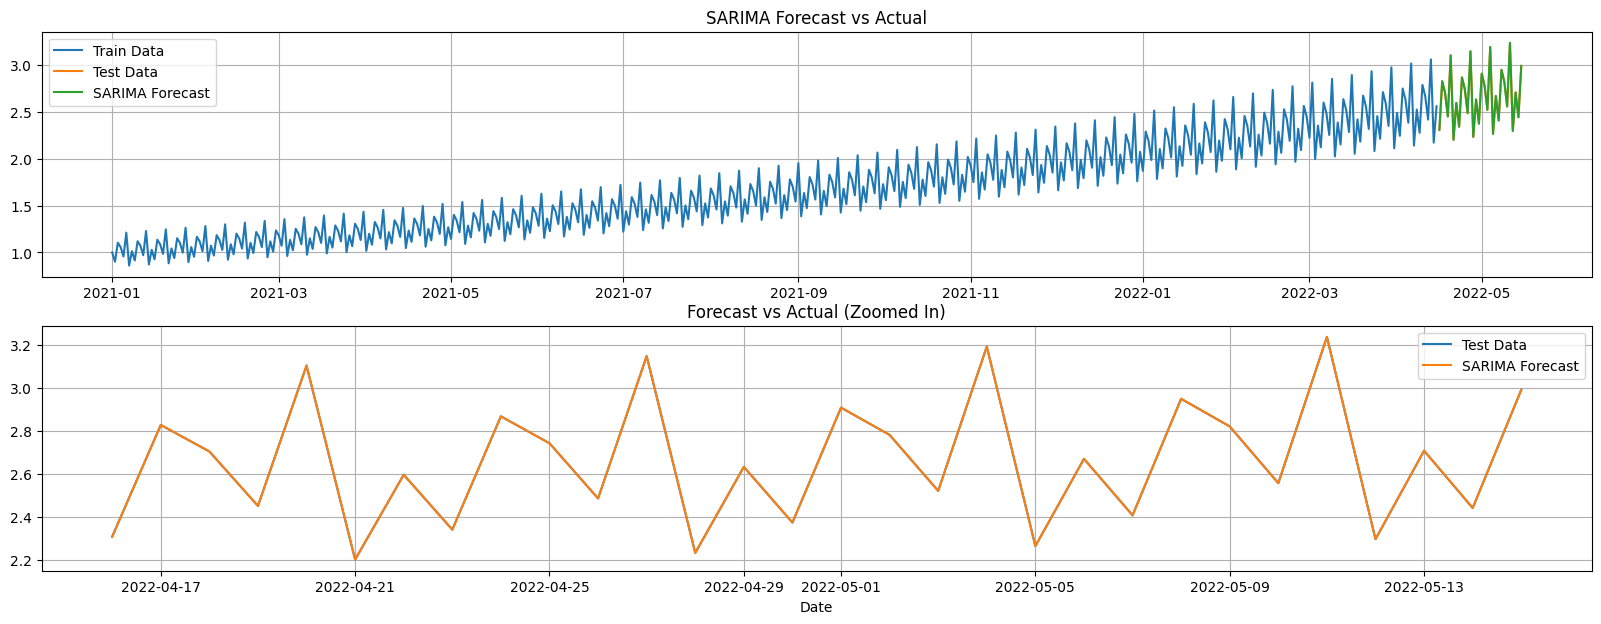

In [ ]:
plt.figure(figsize=(20, 7))
plt.subplot(2, 1, 1)
plt.plot(train_data.index, train_data['Value'], label='Train Data')
plt.plot(test_data.index, test_data['Value'], label='Test Data')
plt.plot(tes_pred.index, tes_pred, label='SARIMA Forecast')
plt.legend()
plt.grid()
plt.title('SARIMA Forecast vs Actual')

plt.subplot(2, 1, 2)
plt.plot(test_data.index, test_data['Value'], label='Test Data')
plt.plot(tes_pred.index, tes_pred, label='SARIMA Forecast')
plt.legend()
plt.grid()
plt.xlabel('Date')
plt.title('Forecast vs Actual (Zoomed In)')
plt.show()

In [ ]:
sarima_pred = sarima_fit.forecast(steps=forecast_horizon)

In [ ]:
y_true = test_data['Value'].values

# Compute metrics
mae = mean_absolute_error(y_true, sarima_pred)
mse = mean_squared_error(y_true, sarima_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, sarima_pred)

# Display results
print(f"3. Using your best model, write the MAE, MSE, RMSE, and MAPE values.")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

3. Using your best model, write the MAE, MSE, RMSE, and MAPE values.
MAE: 9.453251677745319e-09
MSE: 5.469488856552745e-16
RMSE: 2.338693835574196e-08
MAPE: 3.4970654434038736e-09


In [ ]:
sarima_model = SARIMAX(
    ts['Value'],
    order=(2, 1, 2),  # ARIMA(p,d,q) order
    seasonal_order=(1, 1, 2, 7),  # Seasonal order (P,D,Q,S)
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

forecast_30 = sarima_fit.predict(start = len(ts["Value"]), end = len(ts["Value"]) + 30)

# Print forecasted values for specific dates
print(f"4. Using your best model (at 30 days test set), what is the forecast at 2022-05-22?")
print("Forecast at 2022-05-22:", forecast_30.loc['2022-05-22'])
print(f"\n5. Using your best model (with forecast horizon of 30), what is the forecast at 2022-06-08?")
print("Forecast at 2022-06-08:", forecast_30.loc['2022-06-08'])

4. Using your best model (at 30 days test set), what is the forecast at 2022-05-22?
Forecast at 2022-05-22: 3.0323510364978294

5. Using your best model (with forecast horizon of 30), what is the forecast at 2022-06-08?
Forecast at 2022-06-08: 3.4226513291323126
